In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Combined the latest 6-month datasets

files = [
    "data/CRMLSSold202512.csv",
    "data/CRMLSSold202601.csv",
    "data/CRMLSSold202602.csv",
    "data/CRMLSSold202603.csv",
    "data/CRMLSSold202604.csv",
    "data/CRMLSSold202605.csv",
]

df = pd.concat([pd.read_csv(file) for file in files], ignore_index=True)

print(df.shape)

/var/folders/fc/gqd35_1j453fd07q0583s4840000gn/T/ipykernel_97516/1949608247.py:12: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(file) for file in files], ignore_index=True)


(112697, 80)


In [4]:
# Filter to Residential Single Family
df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

In [5]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Rows: 55582
Columns: 80


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName
0,ContraCosta,ContraCosta,"Carpet,Tile,Wood",NaN,NaN,NaN,False,1998000.0,1150041639,teresa@teresahooper.com,...,NaN,False,3.0,San Ramon Valley,94596,975.0,10080.0,NaN,NaN,NaN
2,SanDiego,SanDiego,"Carpet,Wood",True,NaN,NaN,False,2214421.0,1150038683,laura@lauralothianrealestate.com,...,NaN,False,3.0,NaN,91364,NaN,34745.0,NaN,NaN,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,1200000.0,1150038607,trung.lam@kw.com,...,NaN,False,2.0,Other,95121,NaN,6600.0,NaN,NaN,NaN
7,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,3100000.0,1150032869,vickie@realsmartgroup.com,...,NaN,False,1.0,San Jose Unified,95124,NaN,8262.0,NaN,NaN,NaN
9,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,2900000.0,1150028403,vickie@realsmartgroup.com,...,NaN,False,2.0,Other,95128,NaN,9222.0,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55582 entries, 0 to 112693
Data columns (total 80 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BuyerAgentAOR                 51709 non-null  object 
 1   ListAgentAOR                  55566 non-null  object 
 2   Flooring                      35280 non-null  object 
 3   ViewYN                        50521 non-null  object 
 4   WaterfrontYN                  35 non-null     object 
 5   BasementYN                    1332 non-null   object 
 6   PoolPrivateYN                 51107 non-null  object 
 7   OriginalListPrice             55425 non-null  float64
 8   ListingKey                    55582 non-null  int64  
 9   ListAgentEmail                17900 non-null  object 
 10  CloseDate                     55582 non-null  object 
 11  ClosePrice                    55582 non-null  float64
 12  ListAgentFirstName            55235 non-null  object 
 13  ListA

In [7]:
df.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,5.542500e+04,5.558200e+04,5.558200e+04,55327.000000,55327.000000,55552.000000,5.558200e+04,55582.000000,0.0,0.0,...,0.0,409.000000,0.0,49616.000000,5.455300e+04,33391.000000,53440.000000,39251.00000,5.454900e+04,0.0
mean,1.356305e+06,1.146908e+09,1.278791e+06,34.729230,-118.588966,2051.613918,1.273849e+06,39.413011,NaN,NaN,...,NaN,54.885086,NaN,1.350955,1.959198e+04,2.266299,2.003649,112.37750,3.419258e+05,NaN
std,5.781800e+06,1.268421e+07,2.453080e+06,1.792573,3.322635,1029.032378,1.519307e+06,55.333559,NaN,NaN,...,NaN,219.830425,NaN,0.477274,2.125446e+05,1.457906,3.491084,381.21903,1.679085e+07,NaN
min,0.000000e+00,4.217759e+08,1.750000e+00,0.000000,-124.175789,0.000000,8.000000e+03,-39.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000e+00,NaN
25%,6.360000e+05,1.144786e+09,6.250000e+05,33.753850,-119.162776,1384.000000,6.250000e+05,7.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.380000e+03,1.000000,2.000000,0.00000,5.663000e+03,NaN
50%,8.990000e+05,1.150854e+09,9.000000e+05,34.079562,-118.026571,1824.000000,8.990000e+05,17.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.004000e+03,3.000000,2.000000,0.00000,7.245000e+03,NaN
75%,1.449999e+06,1.154488e+09,1.439875e+06,34.859982,-117.253017,2450.000000,1.400000e+06,50.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,9.875000e+03,3.000000,2.000000,135.00000,1.045400e+04,NaN
max,7.250000e+08,1.176160e+09,4.720000e+08,43.784440,118.140030,23314.000000,6.500000e+07,894.000000,NaN,NaN,...,NaN,2031.000000,NaN,2.000000,3.164242e+07,44.000000,600.000000,20712.00000,1.897474e+09,NaN


In [11]:
# Check missing values
df[[
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]].isna().sum()

ClosePrice                  0
LivingArea                 30
BedroomsTotal               0
BathroomsTotalInteger       1
LotSizeSquareFeet        1033
dtype: int64

In [9]:
# Columns required for EDA
eda_cols = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]

eda_df = df[eda_cols].copy()
eda_df.head()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
0,1998000.0,2045.0,4.0,2.0,10080.0
2,2214421.0,3050.0,4.0,4.0,34745.0
3,1200000.0,1594.0,4.0,2.0,6600.0
7,3100000.0,2700.0,5.0,3.0,8262.0
9,2900000.0,2948.0,5.0,4.0,9222.0


In [10]:
# Summary statistics for required columns
eda_df.describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
count,5.558200e+04,55552.000000,55582.000000,55581.000000,5.454900e+04
mean,1.278791e+06,2051.613918,3.497391,2.641154,3.419258e+05
std,2.453080e+06,1029.032378,0.963999,1.132685,1.679085e+07
min,1.750000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,6.250000e+05,1384.000000,3.000000,2.000000,5.663000e+03
50%,9.000000e+05,1824.000000,3.000000,2.000000,7.245000e+03
75%,1.439875e+06,2450.000000,4.000000,3.000000,1.045400e+04
max,4.720000e+08,23314.000000,22.000000,22.000000,1.897474e+09


In [11]:
# Missing value percentage
missing_summary = pd.DataFrame({
    "missing_count": eda_df.isna().sum(),
    "missing_percent": eda_df.isna().mean() * 100
})

missing_summary

,missing_count,missing_percent
ClosePrice,0,0.000000
LivingArea,30,0.053974
BedroomsTotal,0,0.000000
BathroomsTotalInteger,1,0.001799
LotSizeSquareFeet,1033,1.858515


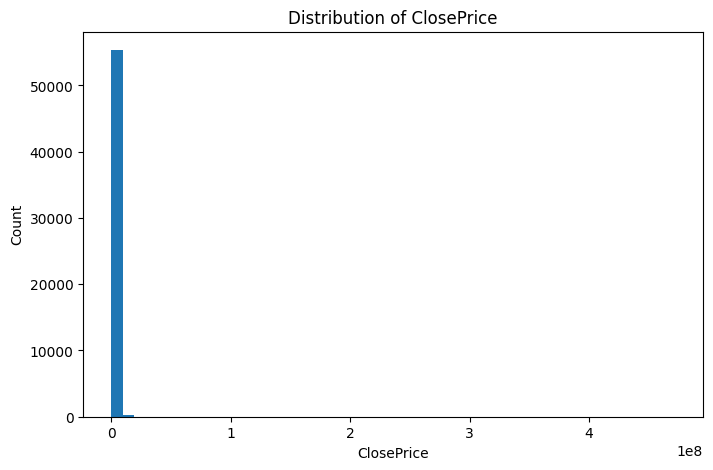

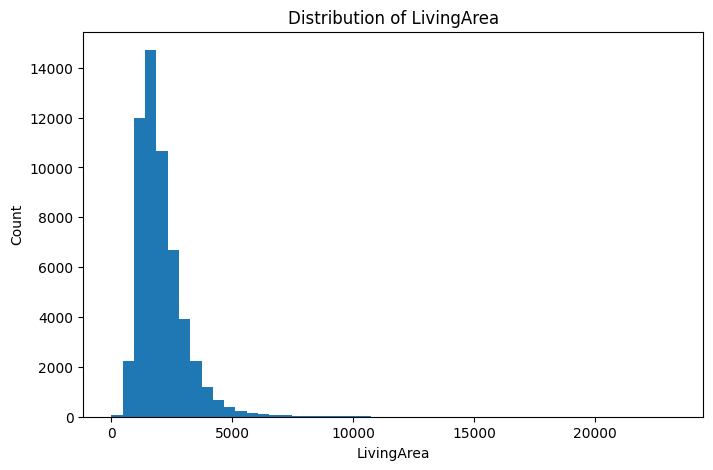

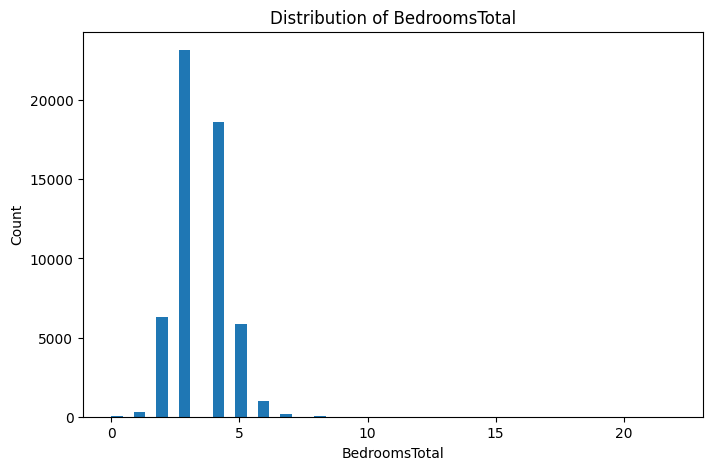

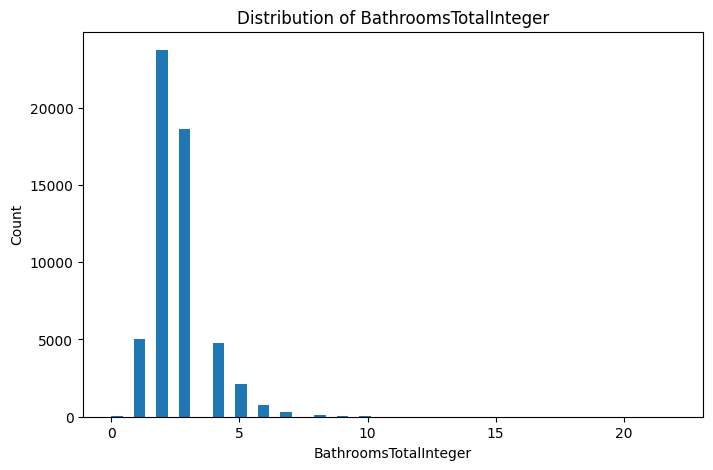

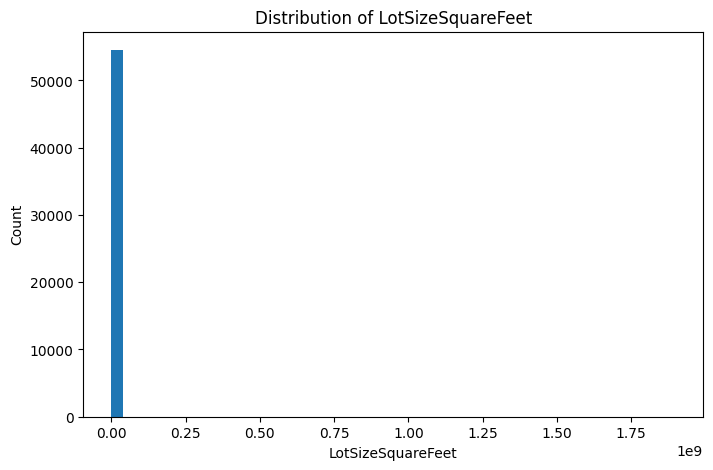

In [12]:
# Basic histograms
for col in eda_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(eda_df[col].dropna(), bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [13]:
# Remove obvious invalid values for clearer plots
eda_clean = eda_df[
    (eda_df["ClosePrice"] > 0) &
    (eda_df["LivingArea"] > 0) &
    (eda_df["BedroomsTotal"] > 0) &
    (eda_df["BathroomsTotalInteger"] > 0) &
    (eda_df["LotSizeSquareFeet"] > 0)
].copy()

print(eda_clean.shape)

(54426, 5)


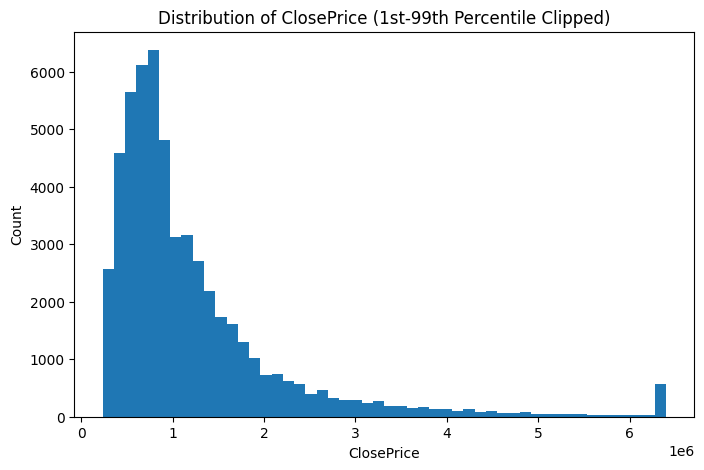

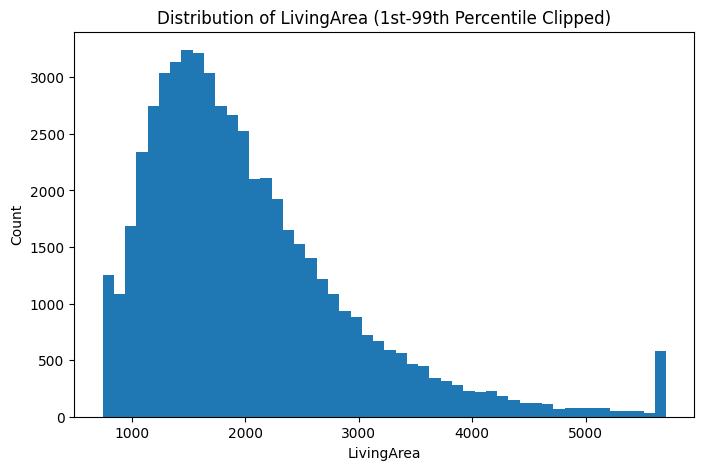

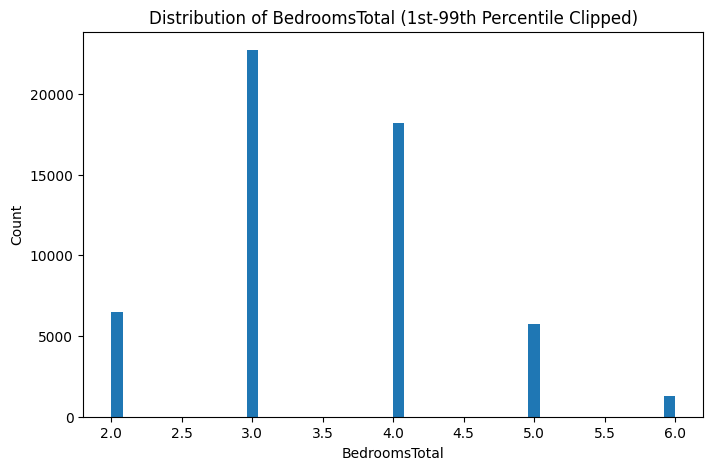

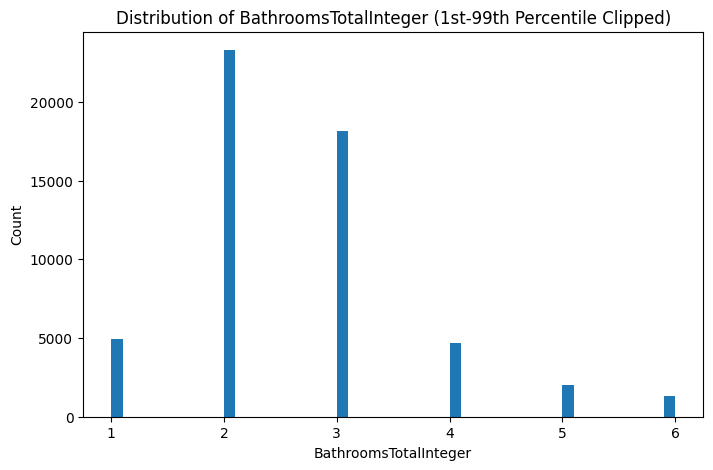

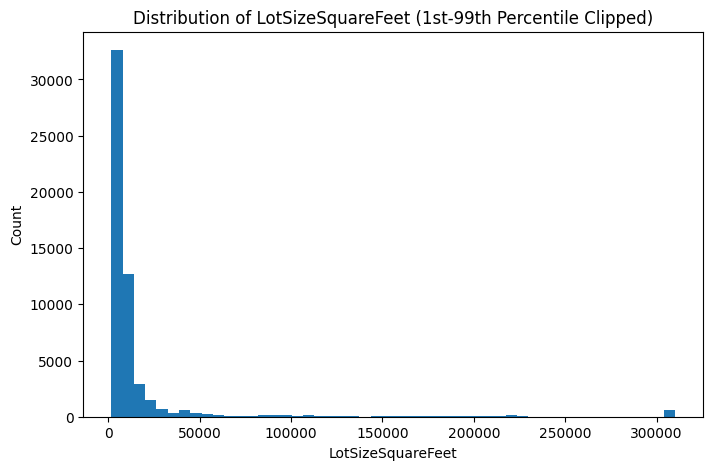

In [14]:
# Clipped histograms to reduce effect of extreme outliers
for col in eda_cols:
    lower = eda_clean[col].quantile(0.01)
    upper = eda_clean[col].quantile(0.99)

    plt.figure(figsize=(8, 5))
    plt.hist(eda_clean[col].clip(lower, upper), bins=50)
    plt.title(f"Distribution of {col} (1st-99th Percentile Clipped)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

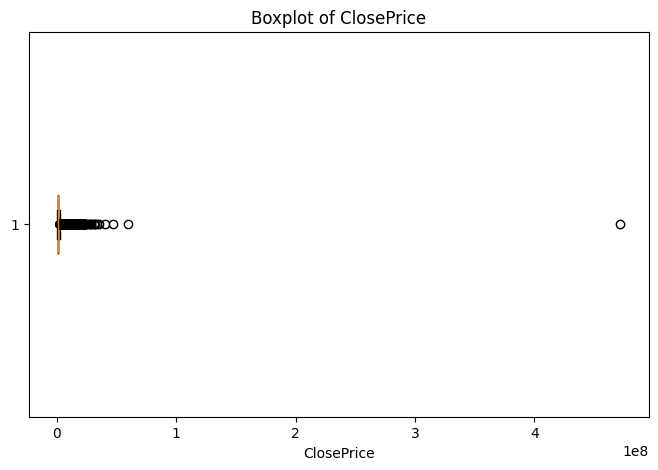

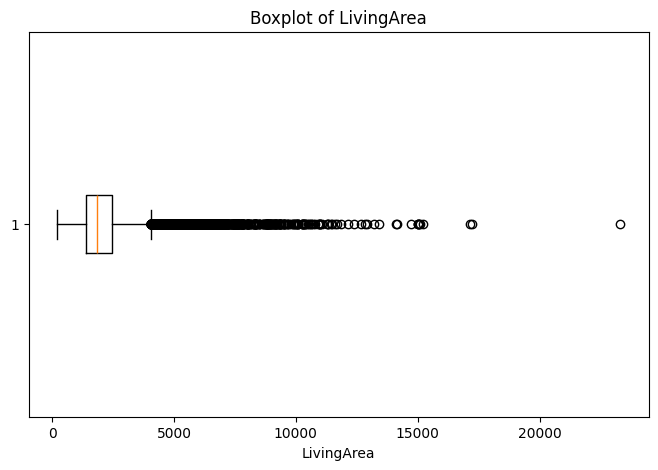

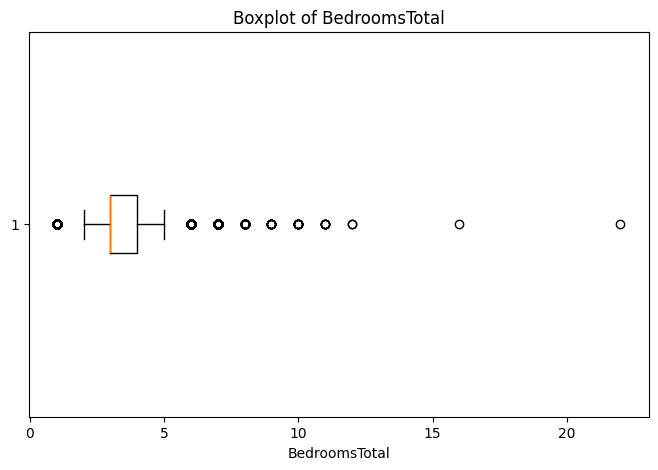

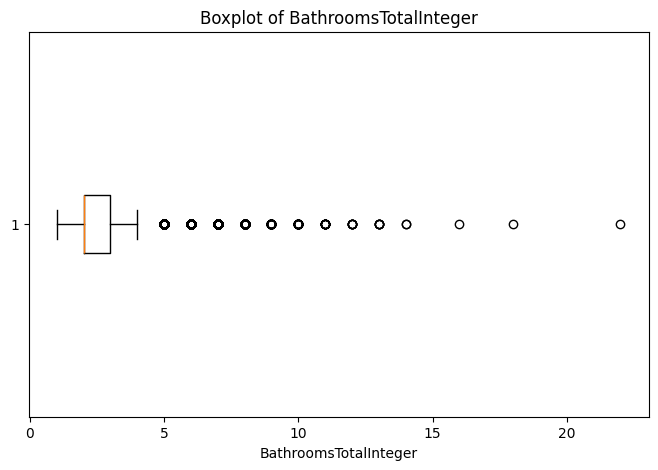

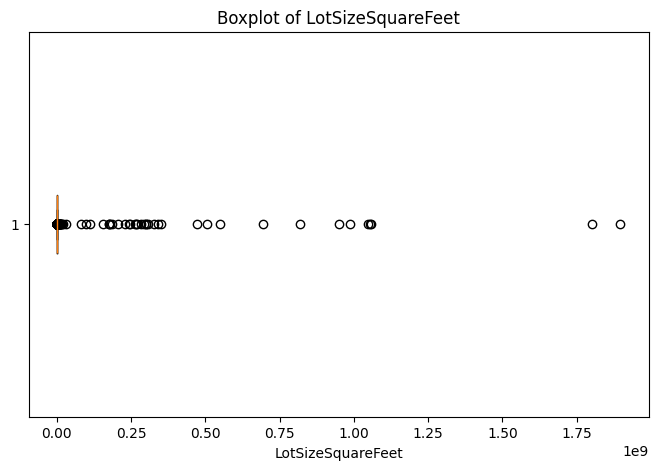

In [15]:
# Boxplots for outlier checking
for col in eda_cols:
    plt.figure(figsize=(8, 5))
    plt.boxplot(eda_clean[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

The dataset was filtered to Residential SingleFamilyResidence properties, leaving 55,582 rows. The main EDA columns are ClosePrice, LivingArea, BedroomsTotal, BathroomsTotalInteger, and LotSizeSquareFeet. ClosePrice and LotSizeSquareFeet show strong right-skew, meaning most homes are clustered at lower values while a small number of expensive or large-lot properties create extreme outliers. To make the distributions easier to interpret, I also plotted clipped versions using the 1st and 99th percentiles.